# Моделирование температуры сплава в тигель ковше
Выпускной проект

## Описание
Чтобы оптимизировать производственные расходы, металлургический комбинат «Стальная птица» решил уменьшить потребление электроэнергии на этапе обработки стали. Для этого комбинату нужно контролировать температуру сплава. Наша задача — построить модель, которая будет её предсказывать. 

## План работы

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

## Загрузка данных

In [2]:
def load_dataset(name, parse_dates=None, sep=',', decimal='.'):
	df = pd.DataFrame()
	try:
		df = pd.read_csv(f'./datasets/{name}_new.csv', sep=sep, decimal=decimal, index_col='key', parse_dates=parse_dates)
		print(f'{name} загружен из локальной папки')
	except:
		df = pd.read_csv(f'https://code.s3.yandex.net/datasets/{name}_new.csv', sep=sep, decimal=decimal, index_col='key', parse_dates=parse_dates)
		print(f'{name} загружен из облака')
	df.sort_index(inplace=True)
	return df

In [3]:
data_arc		= load_dataset('data_arc', parse_dates=['Начало нагрева дугой', 'Конец нагрева дугой'])
data_bulk		= load_dataset('data_bulk')
data_bulk_time	= load_dataset('data_bulk_time', parse_dates=list(range(1, data_bulk.shape[1] + 1)))
data_gas		= load_dataset('data_gas')
data_temp		= load_dataset('data_temp', parse_dates=[1])
data_wire		= load_dataset('data_wire')
data_wire_time	= load_dataset('data_wire_time', parse_dates=list(range(1, data_wire.shape[1] + 1)))

data_arc загружен из локальной папки
data_bulk загружен из локальной папки
data_bulk_time загружен из локальной папки
data_gas загружен из локальной папки
data_temp загружен из локальной папки
data_wire загружен из локальной папки
data_wire_time загружен из локальной папки


## Осмотр данных

In [4]:
"""
Рисует гистограмму и ящик с усами для количественных непрерывных признаков
"""
def plot_col(df, col, axs, cat_target):
	ax = sns.histplot(data=df, x=col, hue=cat_target, bins=50, ax=axs[0]);
	ax.set_xlabel(None)
	ax.set_ylabel(col)
	ax = sns.boxplot(data=df, x=col, ax=axs[1]);
	ax.set_yticklabels([])
	ax.set_xlabel(None)

def plot_num_cont(df_raw, cols=None, cat_target=None):
	df = df_raw.reset_index(drop=True)
	if not cols: cols = df.select_dtypes(include='float64').columns
	row_count = len(cols)
	if row_count == 0:
		return
	fig, axs = plt.subplots(row_count, 2)
	fig.set_size_inches(12, 3 * row_count)
	if len(cols) == 1:
		plot_col(df, cols[0], axs, cat_target)
	else:
		row_idx = 0
		for col in cols:
			plot_col(df, col, axs[row_idx], cat_target)
			row_idx += 1

def explore_df(df):
	print('-' * 100)
	print('sample:')
	display(df.sample(5))
	print('-' * 100)
	print('\ninfo:\n')
	df.info()
	print('-' * 100)
	print('\ndescribe:\n')
	display(df.describe())
	print('-' * 100)
	print('\nduplicates:\n')
	print(f'id duplicates: {df.index.duplicated().sum()}, full row duplicates: {df.duplicated().sum()}')
	print('-' * 100)
	print('\nunique keys:\n')
	print(df.index.unique().size)
	plot_num_cont(df)

### data_arc
данные о нагреве электродами

- у data_wire такой же принцип структуры, как у bulk
- и так же нет очевидных выбросов

- у data_wire такой же принцип структуры, как у bulk
- и так же нет очевидных выбросов

----------------------------------------------------------------------------------------------------
sample:


,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность
key,,,,
1123,2019-06-15 06:35:33,2019-06-15 06:37:51,0.412417,0.276180
421,2019-05-19 13:54:47,2019-05-19 13:56:56,0.540049,0.476166
638,2019-05-27 18:07:47,2019-05-27 18:09:18,1.241074,0.834739
485,2019-05-22 03:07:58,2019-05-22 03:10:10,1.073564,0.771164
2840,2019-08-23 06:02:15,2019-08-23 06:04:52,0.567078,0.423793


----------------------------------------------------------------------------------------------------

info:

<class 'pandas.core.frame.DataFrame'>
Index: 14876 entries, 1 to 3241
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Начало нагрева дугой  14876 non-null  datetime64[ns]
 1   Конец нагрева дугой   14876 non-null  datetime64[ns]
 2   Активная мощность     14876 non-null  float64       
 3   Реактивная мощность   14876 non-null  float64       
dtypes: datetime64[ns](2), float64(2)
memory usage: 581.1 KB
----------------------------------------------------------------------------------------------------

describe:



,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность
count,14876,14876,14876.000000,14876.000000
mean,2019-07-05 12:25:51.921081088,2019-07-05 12:28:43.592027392,0.662752,0.438986
min,2019-05-03 11:02:14,2019-05-03 11:06:02,0.223120,-715.479924
25%,2019-06-03 23:18:23.249999872,2019-06-03 23:21:35,0.467115,0.337175
50%,2019-07-03 01:31:26.500000,2019-07-03 01:35:13,0.599587,0.441639
75%,2019-08-07 22:52:20.750000128,2019-08-07 22:56:47,0.830070,0.608201
max,2019-09-06 17:24:54,2019-09-06 17:26:15,1.463773,1.270284
std,NaN,NaN,0.258885,5.873485


----------------------------------------------------------------------------------------------------

duplicates:

id duplicates: 11662, full row duplicates: 0
----------------------------------------------------------------------------------------------------

unique keys:

3214


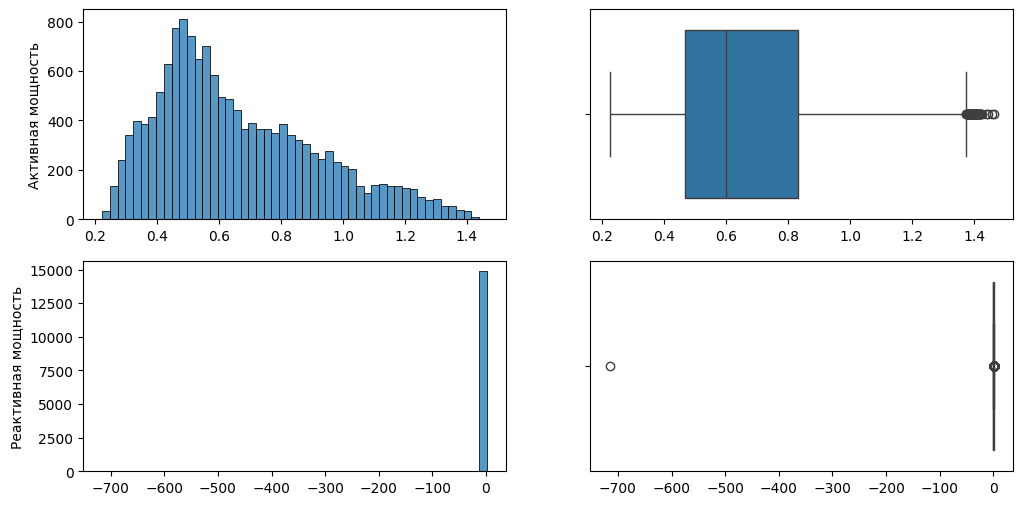

In [5]:
explore_df(data_arc)

- каждая запись - один цикл нагрева ковша с времением начала и конца и параметрами мощности
- по каждому ковшу как правило есть несколько записей - несколько циклов
- аномальный минимум в Реактивной мощности
- пропусков нет
- полных дубликатов нет

### data_bulk
данные о подаче сыпучих материалов (объём)

----------------------------------------------------------------------------------------------------
sample:


,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
key,,,,,,,,,,,,,,,
2367,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,410.0,NaN,184.0,NaN
417,NaN,NaN,99.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,178.0,NaN
1718,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75.0,NaN,NaN,NaN,NaN,NaN
3120,NaN,NaN,NaN,NaN,54.0,128.0,NaN,NaN,NaN,NaN,NaN,208.0,NaN,92.0,108.0
2564,38.0,254.0,NaN,62.0,128.0,NaN,296.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


----------------------------------------------------------------------------------------------------

info:

<class 'pandas.core.frame.DataFrame'>
Index: 3129 entries, 1 to 3241
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Bulk 1   252 non-null    float64
 1   Bulk 2   22 non-null     float64
 2   Bulk 3   1298 non-null   float64
 3   Bulk 4   1014 non-null   float64
 4   Bulk 5   77 non-null     float64
 5   Bulk 6   576 non-null    float64
 6   Bulk 7   25 non-null     float64
 7   Bulk 8   1 non-null      float64
 8   Bulk 9   19 non-null     float64
 9   Bulk 10  176 non-null    float64
 10  Bulk 11  177 non-null    float64
 11  Bulk 12  2450 non-null   float64
 12  Bulk 13  18 non-null     float64
 13  Bulk 14  2806 non-null   float64
 14  Bulk 15  2248 non-null   float64
dtypes: float64(15)
memory usage: 391.1 KB
----------------------------------------------------------------------------------------------------

,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
count,252.000000,22.000000,1298.000000,1014.000000,77.000000,576.000000,25.000000,1.0,19.000000,176.000000,177.000000,2450.000000,18.000000,2806.000000,2248.000000
mean,39.242063,253.045455,113.879045,104.394477,107.025974,118.925347,305.600000,49.0,76.315789,83.284091,76.819209,260.471020,181.111111,170.284747,160.513345
std,18.277654,21.180578,75.483494,48.184126,81.790646,72.057776,191.022904,NaN,21.720581,26.060347,59.655365,120.649269,46.088009,65.868652,51.765319
min,10.000000,228.000000,6.000000,12.000000,11.000000,17.000000,47.000000,49.0,63.000000,24.000000,8.000000,53.000000,151.000000,16.000000,1.000000
25%,27.000000,242.000000,58.000000,72.000000,70.000000,69.750000,155.000000,49.0,66.000000,64.000000,25.000000,204.000000,153.250000,119.000000,105.000000
50%,31.000000,251.500000,97.500000,102.000000,86.000000,100.000000,298.000000,49.0,68.000000,86.500000,64.000000,208.000000,155.500000,151.000000,160.000000
75%,46.000000,257.750000,152.000000,133.000000,132.000000,157.000000,406.000000,49.0,70.500000,102.000000,106.000000,316.000000,203.500000,205.750000,205.000000
max,185.000000,325.000000,454.000000,281.000000,603.000000,503.000000,772.000000,49.0,147.000000,159.000000,313.000000,1849.000000,305.000000,636.000000,405.000000


----------------------------------------------------------------------------------------------------

duplicates:

id duplicates: 0, full row duplicates: 80
----------------------------------------------------------------------------------------------------

unique keys:

3129


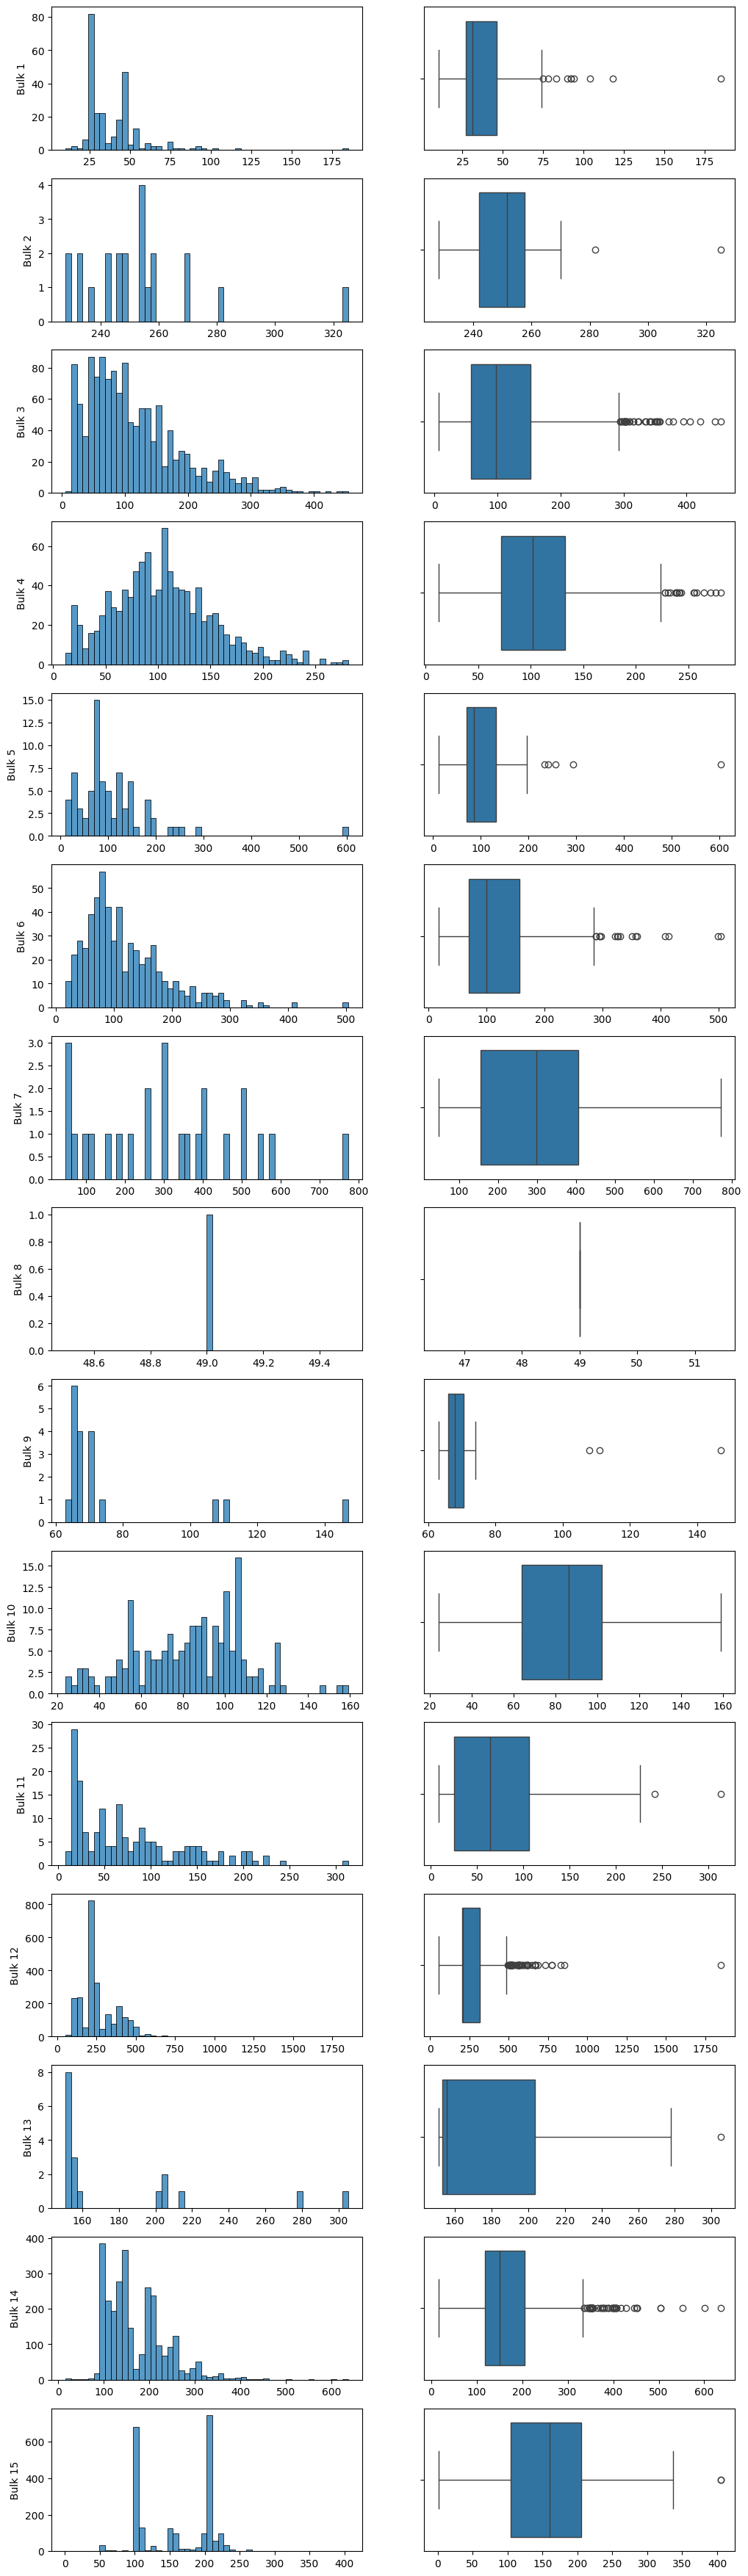

In [6]:
explore_df(data_bulk)

- здесь один ковш - одна запись. колонки по всей видимости соответствуют различным материалам - их поданному в ковш объему
- пропуски видимо значат, что такой материал не применялся, т.е. стоит заменить их на 0
- оценить здесь, что есть выбросы, без дополнительной информации сложно, но явных (отрицательных или огромных, нет)
- дубликатов по ключу нет

### data_bulk_time
данные о подаче сыпучих материалов (время)

In [7]:
explore_df(data_bulk_time)

----------------------------------------------------------------------------------------------------
sample:


,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
key,,,,,,,,,,,,,,,
1785,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-07-08 16:21:50,NaT
1931,NaT,NaT,2019-07-19 21:10:29,NaT,NaT,2019-07-19 21:03:34,NaT,NaT,NaT,NaT,2019-07-19 20:59:43,NaT,NaT,2019-07-19 20:55:02,NaT
950,2019-06-09 10:16:31,NaT,NaT,NaT,NaT,2019-06-09 10:16:31,NaT,NaT,NaT,NaT,NaT,2019-06-09 09:54:01,NaT,2019-06-09 10:16:31,2019-06-09 10:06:44
294,NaT,NaT,NaT,2019-05-14 21:23:40,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-14 21:19:25,2019-05-14 21:13:29
494,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-22 10:18:51,NaT,2019-05-22 10:18:51,NaT,2019-05-22 10:14:59,2019-05-22 10:05:55


----------------------------------------------------------------------------------------------------

info:

<class 'pandas.core.frame.DataFrame'>
Index: 3129 entries, 1 to 3241
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Bulk 1   252 non-null    datetime64[ns]
 1   Bulk 2   22 non-null     datetime64[ns]
 2   Bulk 3   1298 non-null   datetime64[ns]
 3   Bulk 4   1014 non-null   datetime64[ns]
 4   Bulk 5   77 non-null     datetime64[ns]
 5   Bulk 6   576 non-null    datetime64[ns]
 6   Bulk 7   25 non-null     datetime64[ns]
 7   Bulk 8   1 non-null      datetime64[ns]
 8   Bulk 9   19 non-null     datetime64[ns]
 9   Bulk 10  176 non-null    datetime64[ns]
 10  Bulk 11  177 non-null    datetime64[ns]
 11  Bulk 12  2450 non-null   datetime64[ns]
 12  Bulk 13  18 non-null     datetime64[ns]
 13  Bulk 14  2806 non-null   datetime64[ns]
 14  Bulk 15  2248 non-null   datetime64[ns]
dtypes: datetime64[ns](1

,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
count,252,22,1298,1014,77,576,25,1,19,176,177,2450,18,2806,2248
mean,2019-06-29 23:24:44.769841152,2019-07-12 07:57:13.045454592,2019-07-08 13:50:14.630970624,2019-07-03 11:17:28.834319616,2019-07-13 17:18:29.090908928,2019-07-06 13:50:06.345486080,2019-07-27 18:09:05.079999744,2019-07-08 17:14:53,2019-06-23 08:08:47.578947328,2019-07-06 23:55:10.954545408,2019-07-15 07:01:00.615819264,2019-07-05 22:55:11.468571392,2019-07-01 18:32:46.944444416,2019-07-06 07:17:48.372772608,2019-07-06 13:24:51.912366336
min,2019-05-03 17:42:46,2019-05-07 15:39:35,2019-05-03 20:40:25,2019-05-03 11:28:48,2019-05-07 15:19:17,2019-05-03 19:09:15,2019-05-07 18:11:01,2019-07-08 17:14:53,2019-05-14 11:57:58,2019-05-06 07:54:02,2019-05-05 23:43:24,2019-05-03 11:24:31,2019-05-05 02:10:21,2019-05-03 11:14:50,2019-05-03 11:10:43
25%,2019-05-29 14:48:48.500000,2019-05-28 02:29:31.500000,2019-06-08 03:50:23.500000,2019-05-30 21:36:11.249999872,2019-06-19 23:32:44,2019-06-06 22:46:10.500000,2019-07-20 23:48:47,2019-07-08 17:14:53,2019-05-14 14:31:08,2019-06-02 05:12:00.500000,2019-06-14 20:24:48,2019-06-03 12:48:47.249999872,2019-05-29 10:43:31.249999872,2019-06-04 04:50:42,2019-06-04 11:28:18
50%,2019-06-25 11:09:13,2019-07-27 17:18:38.500000,2019-07-04 09:31:42,2019-06-28 03:44:42.500000,2019-07-25 17:59:41,2019-07-09 03:34:57.500000,2019-07-27 18:07:02,2019-07-08 17:14:53,2019-05-14 16:55:09,2019-07-06 07:05:20,2019-07-24 11:17:22,2019-07-03 01:32:00,2019-07-01 12:59:36.500000,2019-07-03 21:54:13.500000,2019-07-03 16:43:28.500000
75%,2019-07-31 05:58:18.249999872,2019-08-13 02:20:08,2019-08-11 01:00:36.750000128,2019-08-04 04:15:46.500000,2019-08-13 04:23:23,2019-08-07 18:55:01.249999872,2019-08-13 04:19:43,2019-07-08 17:14:53,2019-08-16 05:43:31,2019-08-04 02:23:35.750000128,2019-08-11 05:21:01,2019-08-08 14:55:05.249999872,2019-08-04 23:32:00.249999872,2019-08-09 04:22:40.500000,2019-08-09 09:18:31.750000128
max,2019-09-05 09:11:32,2019-08-13 11:47:39,2019-09-06 12:26:52,2019-09-05 03:35:21,2019-09-02 18:16:52,2019-09-06 16:24:28,2019-09-05 19:07:49,2019-07-08 17:14:53,2019-08-16 09:11:56,2019-09-04 10:03:22,2019-09-06 05:03:14,2019-09-06 15:01:44,2019-09-01 01:53:02,2019-09-06 17:26:33,2019-09-06 17:23:15


----------------------------------------------------------------------------------------------------

duplicates:

id duplicates: 0, full row duplicates: 0
----------------------------------------------------------------------------------------------------

unique keys:

3129


- у data_bulk_time структура такая же, как у data_bulk
- дубликатов по ключу нет

### data_gas
данные о продувке сплава газом

----------------------------------------------------------------------------------------------------
sample:


,Газ 1
key,
1101,11.912771
264,10.069828
1176,9.997870
1966,18.710089
1336,7.554531


----------------------------------------------------------------------------------------------------

info:

<class 'pandas.core.frame.DataFrame'>
Index: 3239 entries, 1 to 3241
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Газ 1   3239 non-null   float64
dtypes: float64(1)
memory usage: 50.6 KB
----------------------------------------------------------------------------------------------------

describe:



,Газ 1
count,3239.000000
mean,11.002062
std,6.220327
min,0.008399
25%,7.043089
50%,9.836267
75%,13.769915
max,77.995040


----------------------------------------------------------------------------------------------------

duplicates:

id duplicates: 0, full row duplicates: 0
----------------------------------------------------------------------------------------------------

unique keys:

3239


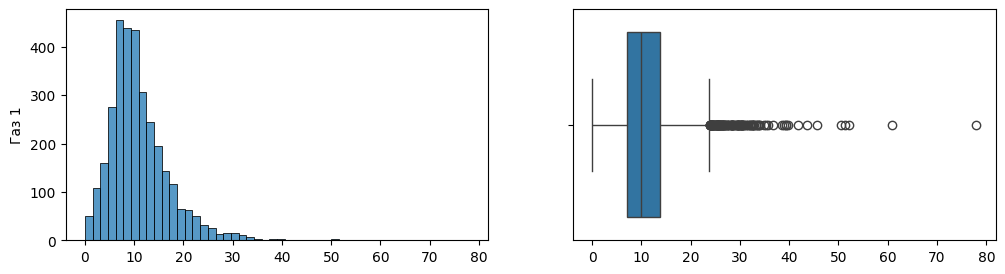

In [8]:
explore_df(data_gas)

- data_gas - просто какой объем газа (видимо, в сумме) был продут через каждый ковш
- дубликатов нет
- лакун нет
- явных выбросов нет

### data_temp
результаты измерения температуры

----------------------------------------------------------------------------------------------------
sample:


,Время замера,Температура
key,,
3034,2019-08-30 15:41:31,1611.0
704,2019-05-30 22:53:20,1589.0
1373,2019-06-24 07:42:59,1600.0
1143,2019-06-16 02:39:54,1596.0
1058,2019-06-13 02:28:54,1579.0


----------------------------------------------------------------------------------------------------

info:

<class 'pandas.core.frame.DataFrame'>
Index: 18092 entries, 1 to 3241
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Время замера  18092 non-null  datetime64[ns]
 1   Температура   14665 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 424.0 KB
----------------------------------------------------------------------------------------------------

describe:



,Время замера,Температура
count,18092,14665.000000
mean,2019-07-05 13:36:58.791620608,1590.722741
min,2019-05-03 11:02:04,1191.000000
25%,2019-06-04 00:35:01.249999872,1580.000000
50%,2019-07-03 02:11:48,1590.000000
75%,2019-08-07 23:10:05.249999872,1599.000000
max,2019-09-06 17:30:05,1705.000000
std,NaN,20.394381


----------------------------------------------------------------------------------------------------

duplicates:

id duplicates: 14876, full row duplicates: 0
----------------------------------------------------------------------------------------------------

unique keys:

3216


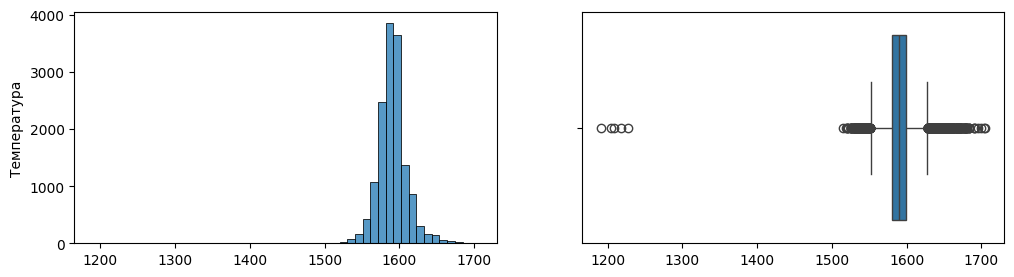

In [9]:
explore_df(data_temp)

- в data_temp каждая запись - один замер (время и температура). как правило по несколько замеров для каждого ковша.
- есть лакуны в поле температуры
- есть значения заведомо ниже температуры плавления сплава (~1400), чего быть не должно - сплав застынет и все - будем считать выбросами
- если не считать выбросы, распределение похоже на нормальное с чуть более вытянутым хвостом в сторону высоких температур

### data_wire
данные о проволочных материалах (объём)

----------------------------------------------------------------------------------------------------
sample:


,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
key,,,,,,,,,
2136,25.072321,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2230,158.121598,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3045,28.173599,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2998,137.810394,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3231,125.667358,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


----------------------------------------------------------------------------------------------------

info:

<class 'pandas.core.frame.DataFrame'>
Index: 3081 entries, 1 to 3241
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Wire 1  3055 non-null   float64
 1   Wire 2  1079 non-null   float64
 2   Wire 3  63 non-null     float64
 3   Wire 4  14 non-null     float64
 4   Wire 5  1 non-null      float64
 5   Wire 6  73 non-null     float64
 6   Wire 7  11 non-null     float64
 7   Wire 8  19 non-null     float64
 8   Wire 9  29 non-null     float64
dtypes: float64(9)
memory usage: 240.7 KB
----------------------------------------------------------------------------------------------------

describe:



,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
count,3055.000000,1079.000000,63.000000,14.000000,1.000,73.000000,11.000000,19.000000,29.000000
mean,100.895853,50.577323,189.482681,57.442841,15.132,48.016974,10.039007,53.625193,34.155752
std,42.012518,39.320216,99.513444,28.824667,NaN,33.919845,8.610584,16.881728,19.931616
min,1.918800,0.030160,0.144144,24.148801,15.132,0.034320,0.234208,45.076721,4.622800
25%,72.115684,20.193680,95.135044,40.807002,15.132,25.053600,6.762756,46.094879,22.058401
50%,100.158234,40.142956,235.194977,45.234282,15.132,42.076324,9.017009,46.279999,30.066399
75%,126.060483,70.227558,276.252014,76.124619,15.132,64.212723,11.886057,48.089603,43.862003
max,330.314424,282.780152,385.008668,113.231044,15.132,180.454575,32.847674,102.762401,90.053604


----------------------------------------------------------------------------------------------------

duplicates:

id duplicates: 0, full row duplicates: 403
----------------------------------------------------------------------------------------------------

unique keys:

3081


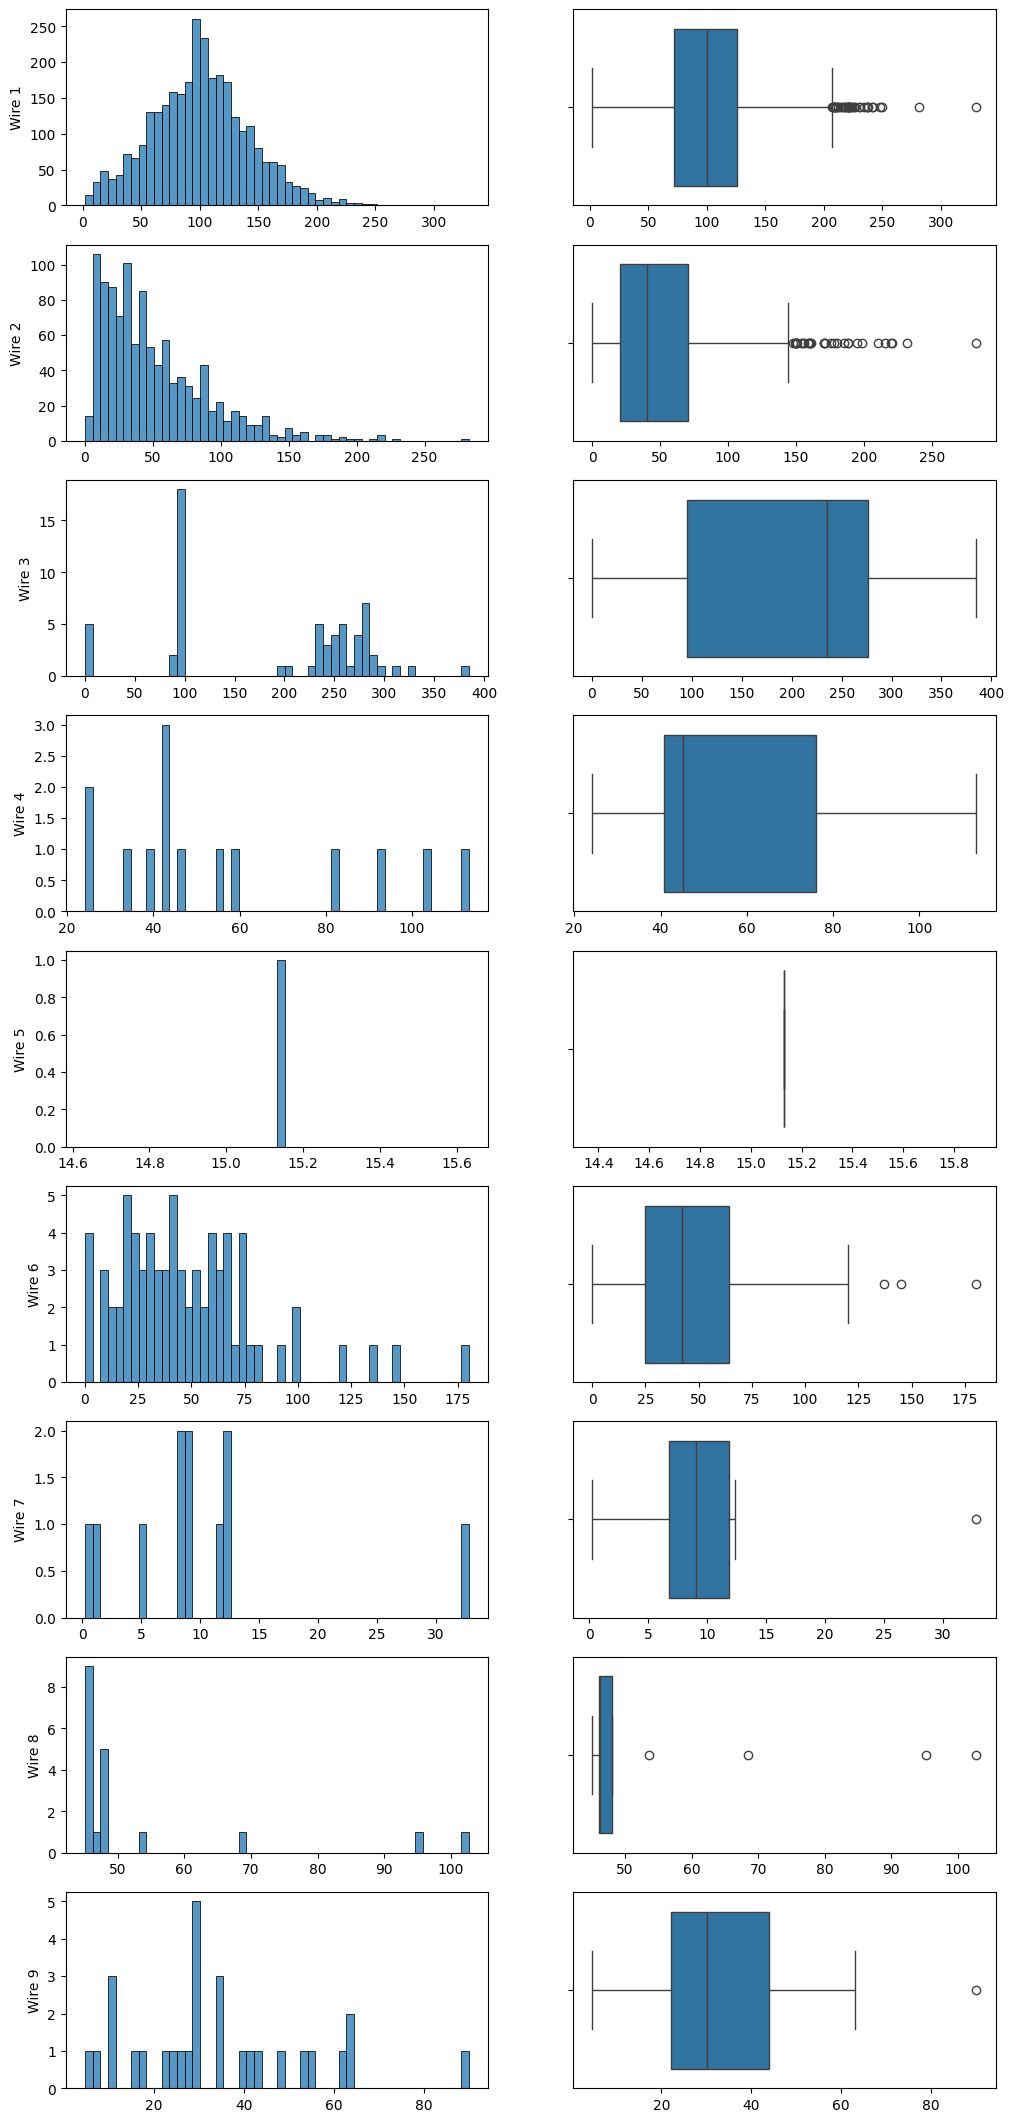

In [10]:
explore_df(data_wire)

- у data_wire такой же принцип структуры, как у bulk
- и так же нет очевидных выбросов
- дубликатов по ключу нет

### data_wire_time
данные о проволочных материалах (время)

In [11]:
explore_df(data_wire_time)

----------------------------------------------------------------------------------------------------
sample:


,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
key,,,,,,,,,
2172,2019-07-30 00:26:16,2019-07-30 00:20:09,NaT,NaT,NaT,NaT,NaT,NaT,NaT
1224,2019-06-18 17:10:20,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
1648,2019-07-03 23:27:13,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
1518,2019-06-29 14:42:50,2019-06-29 14:39:11,NaT,NaT,NaT,NaT,NaT,NaT,NaT
387,2019-05-18 11:34:43,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT


----------------------------------------------------------------------------------------------------

info:

<class 'pandas.core.frame.DataFrame'>
Index: 3081 entries, 1 to 3241
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Wire 1  3055 non-null   datetime64[ns]
 1   Wire 2  1079 non-null   datetime64[ns]
 2   Wire 3  63 non-null     datetime64[ns]
 3   Wire 4  14 non-null     datetime64[ns]
 4   Wire 5  1 non-null      datetime64[ns]
 5   Wire 6  73 non-null     datetime64[ns]
 6   Wire 7  11 non-null     datetime64[ns]
 7   Wire 8  19 non-null     datetime64[ns]
 8   Wire 9  29 non-null     datetime64[ns]
dtypes: datetime64[ns](9)
memory usage: 240.7 KB
----------------------------------------------------------------------------------------------------

describe:



,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
count,3055,1079,63,14,1,73,11,19,29
mean,2019-07-05 23:22:34.279541760,2019-07-07 01:07:08.735866624,2019-07-10 15:09:58.650793472,2019-07-11 13:44:37,2019-08-13 06:14:30,2019-07-07 11:51:15.095890432,2019-08-07 01:16:08.090909184,2019-06-23 07:47:49.052631552,2019-07-01 11:56:04.793103616
min,2019-05-03 11:06:19,2019-05-03 13:15:34,2019-05-04 04:34:27,2019-05-07 15:19:17,2019-08-13 06:14:30,2019-05-07 14:46:05,2019-07-27 05:49:05,2019-05-14 11:29:24,2019-05-04 17:21:27
25%,2019-06-04 19:30:11.500000,2019-06-05 14:50:26.500000,2019-06-11 14:17:38.500000,2019-07-20 17:58:53.750000128,2019-08-13 06:14:30,2019-05-08 21:47:30,2019-07-27 16:27:27,2019-05-14 14:20:07.500000,2019-06-09 19:36:17
50%,2019-07-03 06:36:23,2019-07-04 23:13:39,2019-07-21 10:04:47,2019-07-27 05:45:26.500000,2019-08-13 06:14:30,2019-07-28 05:00:32,2019-08-12 21:48:11,2019-05-14 16:55:09,2019-06-11 10:10:21
75%,2019-08-08 08:56:06.500000,2019-08-08 23:15:17,2019-08-12 22:54:46,2019-07-27 16:20:04.750000128,2019-08-13 06:14:30,2019-08-13 13:33:02,2019-08-13 02:02:55.500000,2019-08-16 05:06:53.500000,2019-08-09 06:49:04
max,2019-09-06 17:10:06,2019-09-06 07:35:40,2019-09-02 07:14:44,2019-08-13 03:16:45,2019-08-13 06:14:30,2019-08-18 19:10:56,2019-08-13 10:25:22,2019-08-16 08:56:23,2019-09-03 12:55:23


----------------------------------------------------------------------------------------------------

duplicates:

id duplicates: 0, full row duplicates: 0
----------------------------------------------------------------------------------------------------

unique keys:

3081


- data_wire_time - то же самое, что для data_wire

### Общие выводы по данным
- Есть две очевидные аномалии:
  - очень низкое значение в реактивной мощности
  - есть значения заведомо ниже температуры плавления сплава (~1400)
- Пропуски для bulk и wire надо заменить нулями
- Характер распределений здесь кроме температуры, наверное, описывать смысла нет, т.к. он определяется технологией процесса
- Желательно переименовать колонки в общепринятом стиле
- Хорошо бы найти метод определить время начала работы с ковшом, тогда можно попробовать перевести все времена для ковша в относительные к времени начала
- Для нагрева электродами можно посчитать продолжительность цикла и работу (активная мощность * продолжительность)
- Реактивная мощность по идее не должна влиять на температуру. Только на затраты энергии
- Дубликатов, которые надо убрать, как будто нет

## Предобработка данных
### Переименования колонок

In [12]:
data_arc.columns = ['arc_start_time', 'arc_end_time', 'arc_active_power', 'arc_reactive_power']
data_bulk.columns = [f'bulk_{x:02}' for x in range(1, data_bulk.shape[1] + 1)]
data_bulk_time.columns = [f'bulk_time_{x:02}' for x in range(1, data_bulk.shape[1] + 1)]
data_gas.columns = ['gas_1']
data_temp.columns = ['temp_time', 'temp']
data_wire.columns = [f'wire_{x:02}' for x in range(1, data_wire.shape[1] + 1)]
data_wire_time.columns = [f'wire_time_{x:02}' for x in range(1, data_wire.shape[1] + 1)]

for df in [data_arc, data_bulk, data_bulk_time, data_gas, data_temp, data_wire, data_wire_time]:
	print(df.columns)

Index(['arc_start_time', 'arc_end_time', 'arc_active_power',
       'arc_reactive_power'],
      dtype='object')
Index(['bulk_01', 'bulk_02', 'bulk_03', 'bulk_04', 'bulk_05', 'bulk_06',
       'bulk_07', 'bulk_08', 'bulk_09', 'bulk_10', 'bulk_11', 'bulk_12',
       'bulk_13', 'bulk_14', 'bulk_15'],
      dtype='object')
Index(['bulk_time_01', 'bulk_time_02', 'bulk_time_03', 'bulk_time_04',
       'bulk_time_05', 'bulk_time_06', 'bulk_time_07', 'bulk_time_08',
       'bulk_time_09', 'bulk_time_10', 'bulk_time_11', 'bulk_time_12',
       'bulk_time_13', 'bulk_time_14', 'bulk_time_15'],
      dtype='object')
Index(['gas_1'], dtype='object')
Index(['temp_time', 'temp'], dtype='object')
Index(['wire_01', 'wire_02', 'wire_03', 'wire_04', 'wire_05', 'wire_06',
       'wire_07', 'wire_08', 'wire_09'],
      dtype='object')
Index(['wire_time_01', 'wire_time_02', 'wire_time_03', 'wire_time_04',
       'wire_time_05', 'wire_time_06', 'wire_time_07', 'wire_time_08',
       'wire_time_09'],
      d

### Убираем аномалии
- очень низкое значение в реактивной мощности
- значения заведомо ниже температуры плавления сплава (~1400)

,arc_start_time,arc_end_time,arc_active_power,arc_reactive_power
key,,,,
2116,2019-07-28 02:22:08,2019-07-28 02:23:57,0.705344,-715.479924


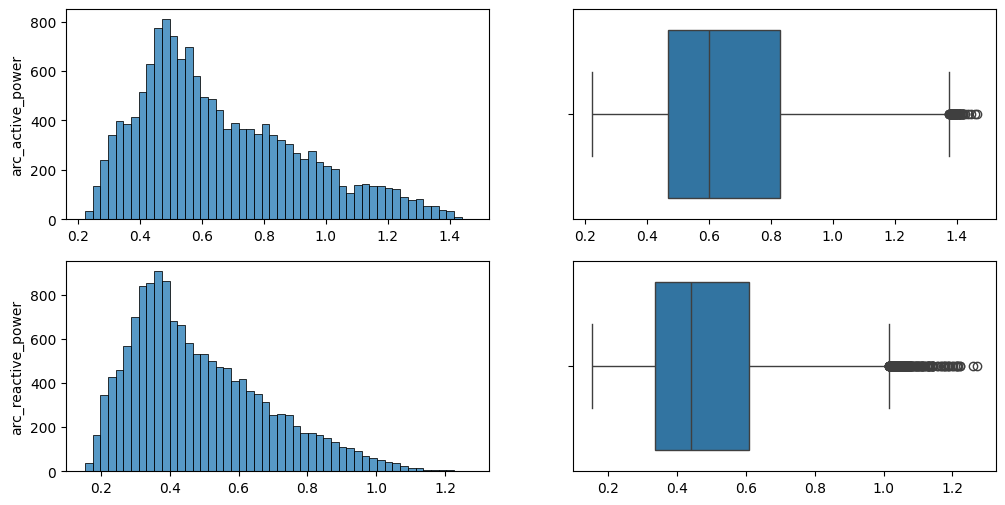

In [13]:
display(data_arc.query('arc_reactive_power < 0'))
data_arc.drop(index=data_arc.query('arc_reactive_power < 0').index, inplace=True)
plot_num_cont(data_arc)

,temp_time,temp
key,,
867,2019-06-06 08:03:39,1191.0
1214,2019-06-18 08:01:03,1208.0
1619,2019-07-03 02:34:41,1218.0
2052,2019-07-25 08:49:15,1227.0
2561,2019-08-12 18:49:29,1204.0


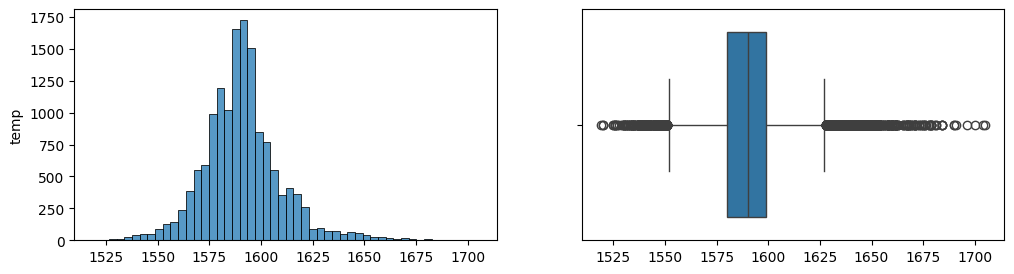

In [14]:
display(data_temp.query('temp < 1400'))
data_temp.drop(index=data_temp.query('temp < 1400').index, inplace=True)
plot_num_cont(data_temp)

### Заменяем пропуски на нули
Там, где это приемлемо: bulk и wire

In [15]:
data_bulk.fillna(value=0, inplace=True)
data_wire.fillna(value=0, inplace=True)
print(data_bulk.isna().sum().sum())
print(data_wire.isna().sum().sum())

0
0


### Удаляем пропуски
В data_temp есть пропуски температуры. Это таргет и измерений для каждого ковша несколько. Наверное, лучше просто удалить пропущенные значения.

In [16]:
data_temp.dropna(inplace=True)
print(data_temp.isna().sum().sum())

0


### Новые признаки в arc
В data_arc надо посчитать работу по нагреву. Т.к. именно от кол-ва джоулей зависит насколько изменится температура.

Для расчета работы возьмем только acive_power, без reacive_power. Т.к."тратится", и соотв. передает энергию только активная составляющая (ну почти только она - реактивная мощность вроде как тоже создает ток, который в среде, обладающей сопротивлением, теряет какую-то часть энергии в тепло, но это не точно).

Длительность нагрева выделим в отдельное поле.

Еще на всякий случай посчитаем полную (кажущуюся) мощность (корень суммы квадратов двух мощностей), и посмотрим, как ее влияение на температуру оценит модель.

In [17]:
data_arc.loc[:, 'arc_duration_sec'] = (data_arc['arc_end_time'] - data_arc['arc_start_time']).dt.seconds
data_arc.loc[:, 'arc_work'] = data_arc['arc_duration_sec'] * data_arc['arc_active_power']
data_arc[['arc_duration_sec', 'arc_active_power', 'arc_work']].sample(3)

,arc_duration_sec,arc_active_power,arc_work
key,,,
760,238,0.304760,72.532880
1692,292,0.817661,238.757012
1256,127,0.534787,67.917949


In [18]:
data_arc.loc[:, 'arc_apparent_power'] = (data_arc['arc_active_power'] ** 2 + data_arc['arc_reactive_power'] ** 2) ** .5
data_arc['arc_apparent_power'].sample(3)

key
2949    0.316609
1670    0.755232
1663    0.890302
Name: arc_apparent_power, dtype: float64

### Объединение данных
Попробуем такой подход: у нас для каждого ковша есть несколько измерений температуры в определенные моменты времени и есть данные по действиям, которые совершали над этим ковшом, тоже с указанием моментов времени. Можно сделать такие обучающие записи: предыдущая температура, результирующая температура, все действия, которые были произведены в промежуток времени между этими двумя измерениями температур.

Здесь, правда, есть теоретическая сложность: если время измерения температуры будет попадать в интервал нагрева, то работу по нагреву придется распределять по двум интервалам температур. Но по идее такого быть не должно: нагревали и измеряли, как будто не одновременно. Посмотрим.

Набор со всеми собранными данными будет называться *data_all*

#### Предыдущая температура в том же ковше
Добавим поля temp_time_prev, temp_prev - предыдущее измерение температуры в ковше. После этого записи с первыми измерениями удалим.

In [19]:
data_all = data_temp.reset_index().sort_values(by=['key', 'temp_time'])
data_all_prev = data_all.groupby(by='key').shift(periods=1, fill_value=None)
data_all = data_all.merge(data_all_prev, how='left', left_index=True, right_index=True, suffixes=('', '_prev'))
del data_all_prev
data_all.set_index('key', inplace=True)
data_all.dropna(inplace=True)
data_all.head(10)


,temp_time,temp,temp_time_prev,temp_prev
key,,,,
1,2019-05-03 11:07:18,1604.0,2019-05-03 11:02:04,1571.0
1,2019-05-03 11:11:34,1618.0,2019-05-03 11:07:18,1604.0
1,2019-05-03 11:18:04,1601.0,2019-05-03 11:11:34,1618.0
1,2019-05-03 11:25:59,1606.0,2019-05-03 11:18:04,1601.0
1,2019-05-03 11:30:38,1613.0,2019-05-03 11:25:59,1606.0
2,2019-05-03 11:38:40,1577.0,2019-05-03 11:34:04,1581.0
2,2019-05-03 11:46:09,1589.0,2019-05-03 11:38:40,1577.0
2,2019-05-03 11:49:38,1604.0,2019-05-03 11:46:09,1589.0
2,2019-05-03 11:55:09,1602.0,2019-05-03 11:49:38,1604.0


Добавим поле - временной интервал между измерениями в секундах

In [20]:
data_all.loc[:, 'temp_interval_sec'] = (data_all['temp_time'] - data_all['temp_time_prev']).dt.seconds

#### Добавляем arc
Сначала просто сольем записи все со всеми по номеру ковша

In [21]:
data_all_raw = data_all.merge(data_arc, how='outer', left_index=True, right_index=True, suffixes=('', ''))
data_all_raw

,temp_time,temp,temp_time_prev,temp_prev,temp_interval_sec,arc_start_time,arc_end_time,arc_active_power,arc_reactive_power,arc_duration_sec,arc_work,arc_apparent_power
key,,,,,,,,,,,,
1,2019-05-03 11:07:18,1604.0,2019-05-03 11:02:04,1571.0,314.0,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253,228.0,69.569640,0.371123
1,2019-05-03 11:07:18,1604.0,2019-05-03 11:02:04,1571.0,314.0,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438,185.0,141.646730,0.902319
1,2019-05-03 11:07:18,1604.0,2019-05-03 11:02:04,1571.0,314.0,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460,172.0,99.813836,0.722536
1,2019-05-03 11:07:18,1604.0,2019-05-03 11:02:04,1571.0,314.0,2019-05-03 11:18:14,2019-05-03 11:24:19,0.518496,0.379979,365.0,189.251040,0.642824
1,2019-05-03 11:07:18,1604.0,2019-05-03 11:02:04,1571.0,314.0,2019-05-03 11:26:09,2019-05-03 11:28:37,0.867133,0.643691,148.0,128.335684,1.079934
...,...,...,...,...,...,...,...,...,...,...,...,...
3241,NaT,NaN,NaT,NaN,NaN,2019-09-06 16:49:05,2019-09-06 16:51:42,0.439735,0.299579,157.0,69.038395,0.532085
3241,NaT,NaN,NaT,NaN,NaN,2019-09-06 16:55:11,2019-09-06 16:58:11,0.646498,0.458240,180.0,116.369640,0.792429
3241,NaT,NaN,NaT,NaN,NaN,2019-09-06 17:06:48,2019-09-06 17:09:52,1.039726,0.769302,184.0,191.309584,1.293389


Теперь оставим только те, где время нагрева попадает в интервал между измерениями температуры, или где не было нагрева

In [22]:
data_all_raw = data_all_raw.query(
	'arc_start_time >= temp_time_prev and arc_start_time <= temp_time or \
	 arc_end_time >= temp_time_prev and arc_end_time <= temp_time or \
	 arc_start_time.isna()'
)
data_all_raw

,temp_time,temp,temp_time_prev,temp_prev,temp_interval_sec,arc_start_time,arc_end_time,arc_active_power,arc_reactive_power,arc_duration_sec,arc_work,arc_apparent_power
key,,,,,,,,,,,,
1,2019-05-03 11:07:18,1604.0,2019-05-03 11:02:04,1571.0,314.0,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253,228.0,69.569640,0.371123
1,2019-05-03 11:11:34,1618.0,2019-05-03 11:07:18,1604.0,256.0,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438,185.0,141.646730,0.902319
1,2019-05-03 11:18:04,1601.0,2019-05-03 11:11:34,1618.0,390.0,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460,172.0,99.813836,0.722536
1,2019-05-03 11:25:59,1606.0,2019-05-03 11:18:04,1601.0,475.0,2019-05-03 11:18:14,2019-05-03 11:24:19,0.518496,0.379979,365.0,189.251040,0.642824
1,2019-05-03 11:30:38,1613.0,2019-05-03 11:25:59,1606.0,279.0,2019-05-03 11:26:09,2019-05-03 11:28:37,0.867133,0.643691,148.0,128.335684,1.079934
...,...,...,...,...,...,...,...,...,...,...,...,...
2498,2019-08-10 13:23:31,1594.0,2019-08-10 13:20:08,1582.0,203.0,2019-08-10 13:20:18,2019-08-10 13:20:59,0.508786,0.363916,41.0,20.860226,0.625538
2499,2019-08-10 13:41:34,1604.0,2019-08-10 13:33:21,1569.0,493.0,2019-08-10 13:33:31,2019-08-10 13:38:43,0.700677,0.534767,312.0,218.611224,0.881433
2499,2019-08-10 13:46:28,1593.0,2019-08-10 13:41:34,1604.0,294.0,2019-08-10 13:41:44,2019-08-10 13:45:09,0.333776,0.269695,205.0,68.424080,0.429117


На всякий случай проверим, как выглядят записи без нагрева

In [23]:
data_all_raw.query('arc_start_time.isna()')

,temp_time,temp,temp_time_prev,temp_prev,temp_interval_sec,arc_start_time,arc_end_time,arc_active_power,arc_reactive_power,arc_duration_sec,arc_work,arc_apparent_power
key,,,,,,,,,,,,
2116,2019-07-28 02:13:00,1574.0,2019-07-28 02:07:02,1579.0,358.0,NaT,NaT,NaN,NaN,NaN,NaN,NaN
2116,2019-07-28 02:21:58,1578.0,2019-07-28 02:13:00,1574.0,538.0,NaT,NaT,NaN,NaN,NaN,NaN,NaN
2116,2019-07-28 02:29:01,1575.0,2019-07-28 02:21:58,1578.0,423.0,NaT,NaT,NaN,NaN,NaN,NaN,NaN
2116,2019-07-28 02:35:36,1578.0,2019-07-28 02:29:01,1575.0,395.0,NaT,NaT,NaN,NaN,NaN,NaN,NaN


В двух случаях не было нагрева и температура росла - так, наверное, может быть, но выглядит странно. Если вспомнить, то мы уже удаляли аномалию мощности из 2116-го ковша. Возможно с ним просто что-то сломалось, лучше его убрать из обучения совсем. 

In [24]:
try:
	data_all_raw = data_all_raw.drop(index=2116)
except:
	pass
data_all_raw.shape

(11428, 12)

Больше интервалов записей без нагрева не осталось

Проверим, есть ли частичные пересечения интервалов между измерениями и интервалов нагрева 

In [25]:
data_all_raw.query('arc_start_time < temp_time_prev or arc_end_time > temp_time').shape[0]

0

Таких нет. Это сильно облегчает задачу

Посмотрим, есть ли несколько циклов нагрева в одном интервале между измерениями температуры 

In [26]:
print((data_all_raw.groupby(by=['key', 'temp_time'])['temp_time'].count() > 1).sum())

0


Тоже нет. Значит temp и arc собрали вместе

In [27]:
data_all = data_all_raw
display(data_all.sample(5))
data_all.shape

,temp_time,temp,temp_time_prev,temp_prev,temp_interval_sec,arc_start_time,arc_end_time,arc_active_power,arc_reactive_power,arc_duration_sec,arc_work,arc_apparent_power
key,,,,,,,,,,,,
1263,2019-06-20 03:03:12,1582.0,2019-06-20 02:53:46,1577.0,566.0,2019-06-20 02:53:56,2019-06-20 03:01:00,0.487159,0.406065,424.0,206.555416,0.634202
2104,2019-07-27 04:12:01,1621.0,2019-07-27 04:06:42,1621.0,319.0,2019-07-27 04:06:52,2019-07-27 04:09:50,0.594104,0.438778,178.0,105.750512,0.738570
83,2019-05-06 14:09:10,1624.0,2019-05-06 14:02:56,1612.0,374.0,2019-05-06 14:03:06,2019-05-06 14:06:16,0.489217,0.361388,190.0,92.951230,0.608222
89,2019-05-06 18:35:48,1577.0,2019-05-06 18:29:19,1581.0,389.0,2019-05-06 18:29:29,2019-05-06 18:33:11,0.825179,0.560673,222.0,183.189738,0.997634
888,2019-06-06 22:41:27,1593.0,2019-06-06 22:33:00,1589.0,507.0,2019-06-06 22:33:10,2019-06-06 22:36:33,0.432041,0.265637,203.0,87.704323,0.507171


(11428, 12)

#### Добавляем bulk
Сначала просто соберем поля вместе

In [28]:
data_all_raw = data_all.\
	merge(data_bulk, how='left', left_index=True, right_index=True, suffixes=('', '')).\
	merge(data_bulk_time, how='left', left_index=True, right_index=True, suffixes=('', ''))
display(data_all_raw.info())

<class 'pandas.core.frame.DataFrame'>
Index: 11428 entries, 1 to 2499
Data columns (total 42 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   temp_time           11428 non-null  datetime64[ns]
 1   temp                11428 non-null  float64       
 2   temp_time_prev      11428 non-null  datetime64[ns]
 3   temp_prev           11428 non-null  float64       
 4   temp_interval_sec   11428 non-null  float64       
 5   arc_start_time      11428 non-null  datetime64[ns]
 6   arc_end_time        11428 non-null  datetime64[ns]
 7   arc_active_power    11428 non-null  float64       
 8   arc_reactive_power  11428 non-null  float64       
 9   arc_duration_sec    11428 non-null  float64       
 10  arc_work            11428 non-null  float64       
 11  arc_apparent_power  11428 non-null  float64       
 12  bulk_01             11208 non-null  float64       
 13  bulk_02             11208 non-null  float64       
 

None

Теперь почистим те bulk, время внесения которых не попадает в интервал между измерениями температуры (здесь может быть долго)

In [29]:
def maybe_clear_additive(df, row_idx, bulk_num, additive):
	additive_col = f'{additive}_{bulk_num:02}'
	additive_time_col = f'{additive}_time_{bulk_num:02}'
	bulk_time = df.loc[row_idx, additive_time_col]
	if bulk_time < df.loc[row_idx, 'temp_time_prev'] or bulk_time > df.loc[row_idx, 'temp_time']:
		df.loc[row_idx, additive_time_col] = pd.NaT
		df.loc[row_idx, additive_col] = 0

def clear_additives(df, additive, additive_count):
	result_df = df.reset_index()
	for row_idx in result_df.index:
		for bulk_num in range(1, additive_count + 1):
			maybe_clear_additive(result_df, row_idx, bulk_num, additive)
	result_df.set_index('key', drop=True, inplace=True)
	return result_df

data_all = clear_additives(data_all_raw, 'bulk', data_bulk.shape[1])

In [30]:
display(data_all_raw.head(5))
display(data_all.head(5))

,temp_time,temp,temp_time_prev,temp_prev,temp_interval_sec,arc_start_time,arc_end_time,arc_active_power,arc_reactive_power,arc_duration_sec,...,bulk_time_06,bulk_time_07,bulk_time_08,bulk_time_09,bulk_time_10,bulk_time_11,bulk_time_12,bulk_time_13,bulk_time_14,bulk_time_15
key,,,,,,,,,,,,,,,,,,,,,
1,2019-05-03 11:07:18,1604.0,2019-05-03 11:02:04,1571.0,314.0,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253,228.0,...,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:24:31,NaT,2019-05-03 11:14:50,2019-05-03 11:10:43
1,2019-05-03 11:11:34,1618.0,2019-05-03 11:07:18,1604.0,256.0,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438,185.0,...,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:24:31,NaT,2019-05-03 11:14:50,2019-05-03 11:10:43
1,2019-05-03 11:18:04,1601.0,2019-05-03 11:11:34,1618.0,390.0,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460,172.0,...,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:24:31,NaT,2019-05-03 11:14:50,2019-05-03 11:10:43
1,2019-05-03 11:25:59,1606.0,2019-05-03 11:18:04,1601.0,475.0,2019-05-03 11:18:14,2019-05-03 11:24:19,0.518496,0.379979,365.0,...,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:24:31,NaT,2019-05-03 11:14:50,2019-05-03 11:10:43
1,2019-05-03 11:30:38,1613.0,2019-05-03 11:25:59,1606.0,279.0,2019-05-03 11:26:09,2019-05-03 11:28:37,0.867133,0.643691,148.0,...,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:24:31,NaT,2019-05-03 11:14:50,2019-05-03 11:10:43


,temp_time,temp,temp_time_prev,temp_prev,temp_interval_sec,arc_start_time,arc_end_time,arc_active_power,arc_reactive_power,arc_duration_sec,...,bulk_time_06,bulk_time_07,bulk_time_08,bulk_time_09,bulk_time_10,bulk_time_11,bulk_time_12,bulk_time_13,bulk_time_14,bulk_time_15
key,,,,,,,,,,,,,,,,,,,,,
1,2019-05-03 11:07:18,1604.0,2019-05-03 11:02:04,1571.0,314.0,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253,228.0,...,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
1,2019-05-03 11:11:34,1618.0,2019-05-03 11:07:18,1604.0,256.0,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438,185.0,...,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:10:43
1,2019-05-03 11:18:04,1601.0,2019-05-03 11:11:34,1618.0,390.0,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460,172.0,...,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:14:50,NaT
1,2019-05-03 11:25:59,1606.0,2019-05-03 11:18:04,1601.0,475.0,2019-05-03 11:18:14,2019-05-03 11:24:19,0.518496,0.379979,365.0,...,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:24:31,NaT,NaT,NaT
1,2019-05-03 11:30:38,1613.0,2019-05-03 11:25:59,1606.0,279.0,2019-05-03 11:26:09,2019-05-03 11:28:37,0.867133,0.643691,148.0,...,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT


Похоже, получилось

#### Добавляем wire
По такой же схеме, как bulk

In [31]:
data_all_raw = data_all.\
	merge(data_wire, how='left', left_index=True, right_index=True, suffixes=('', '')).\
	merge(data_wire_time, how='left', left_index=True, right_index=True, suffixes=('', ''))
display(data_all_raw.info())

data_all = clear_additives(data_all_raw, 'wire', data_wire.shape[1])

<class 'pandas.core.frame.DataFrame'>
Index: 11428 entries, 1 to 2499
Data columns (total 60 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   temp_time           11428 non-null  datetime64[ns]
 1   temp                11428 non-null  float64       
 2   temp_time_prev      11428 non-null  datetime64[ns]
 3   temp_prev           11428 non-null  float64       
 4   temp_interval_sec   11428 non-null  float64       
 5   arc_start_time      11428 non-null  datetime64[ns]
 6   arc_end_time        11428 non-null  datetime64[ns]
 7   arc_active_power    11428 non-null  float64       
 8   arc_reactive_power  11428 non-null  float64       
 9   arc_duration_sec    11428 non-null  float64       
 10  arc_work            11428 non-null  float64       
 11  arc_apparent_power  11428 non-null  float64       
 12  bulk_01             11208 non-null  float64       
 13  bulk_02             11208 non-null  float64       
 

None

In [32]:
print(data_all.shape)
display(data_all.head(10))

(11428, 60)


,temp_time,temp,temp_time_prev,temp_prev,temp_interval_sec,arc_start_time,arc_end_time,arc_active_power,arc_reactive_power,arc_duration_sec,...,wire_09,wire_time_01,wire_time_02,wire_time_03,wire_time_04,wire_time_05,wire_time_06,wire_time_07,wire_time_08,wire_time_09
key,,,,,,,,,,,,,,,,,,,,,
1,2019-05-03 11:07:18,1604.0,2019-05-03 11:02:04,1571.0,314.0,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253,228.0,...,0.0,2019-05-03 11:06:19,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
1,2019-05-03 11:11:34,1618.0,2019-05-03 11:07:18,1604.0,256.0,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438,185.0,...,0.0,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
1,2019-05-03 11:18:04,1601.0,2019-05-03 11:11:34,1618.0,390.0,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460,172.0,...,0.0,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
1,2019-05-03 11:25:59,1606.0,2019-05-03 11:18:04,1601.0,475.0,2019-05-03 11:18:14,2019-05-03 11:24:19,0.518496,0.379979,365.0,...,0.0,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
1,2019-05-03 11:30:38,1613.0,2019-05-03 11:25:59,1606.0,279.0,2019-05-03 11:26:09,2019-05-03 11:28:37,0.867133,0.643691,148.0,...,0.0,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
2,2019-05-03 11:38:40,1577.0,2019-05-03 11:34:04,1581.0,276.0,2019-05-03 11:34:14,2019-05-03 11:36:31,0.381124,0.220351,137.0,...,0.0,2019-05-03 11:36:50,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
2,2019-05-03 11:46:09,1589.0,2019-05-03 11:38:40,1577.0,449.0,2019-05-03 11:38:50,2019-05-03 11:44:28,0.261665,0.205527,338.0,...,0.0,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
2,2019-05-03 11:49:38,1604.0,2019-05-03 11:46:09,1589.0,209.0,2019-05-03 11:46:19,2019-05-03 11:48:25,0.710297,0.484962,126.0,...,0.0,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
2,2019-05-03 11:55:09,1602.0,2019-05-03 11:49:38,1604.0,331.0,2019-05-03 11:49:48,2019-05-03 11:53:18,0.786322,0.542517,210.0,...,0.0,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT


#### Добавляем gas
Здесь простой мерж

In [33]:
data_gas

,gas_1
key,
1,29.749986
2,12.555561
3,28.554793
4,18.841219
5,5.413692
...,...
3237,5.543905
3238,6.745669
3239,16.023518


In [34]:
data_all = data_all.merge(data_gas, how='inner', left_index=True, right_index=True, suffixes=('', ''))

In [35]:
data_all.shape

(11418, 61)

#### Только ключи, которые есть во всех таблицах
У нас есть условие: использовать только те ключи, которые есть во всех таблицах. Т.е. надо проверить, не осталось ли после мержа лакун, допустим, в arc_active_power, bulk_01, wire_01, gas

In [36]:
fields_to_check = ['arc_active_power', 'bulk_01', 'wire_01', 'gas_1']
for fld in fields_to_check:
	print(f'nans in {fld}: {data_all[fld].isna().sum()}')


nans in arc_active_power: 0
nans in bulk_01: 220
nans in wire_01: 376
nans in gas_1: 0


Оказывается, есть. Не все ключи из temp были в bulk и wire. Уберем те, которых не было.

In [37]:
keys_to_drop = data_all.query('bulk_01.isna() or wire_01.isna()').index
print('keys to drop:', keys_to_drop)
data_all.drop(index=keys_to_drop, inplace=True)
data_all.shape

keys to drop: Index([  51,   51,   51,   51,   52,   52,   52,   52,   52,   52,
       ...
       2460, 2460, 2460, 2460, 2468, 2468, 2471, 2471, 2471, 2471],
      dtype='int64', name='key', length=503)


(10915, 61)

#### Убираем все времена
Мы расставили все события по времени, теперь поля со всеми временами можно убрать

In [38]:
data_all.drop(columns=data_all.select_dtypes(include='datetime64[ns]').columns, inplace=True)

Как будто на этом объединение, группировка данных и создание фич закончено

## Исследовательский анализ объединённого датафрейма
Временно заменим все нули на nan. Так будет лучше видно ненулевые значения

In [39]:
data_all_nans = data_all.replace(0., np.nan)

In [40]:
display(data_all_nans.info())

<class 'pandas.core.frame.DataFrame'>
Index: 10915 entries, 1 to 2499
Data columns (total 33 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   temp                10915 non-null  float64
 1   temp_prev           10915 non-null  float64
 2   temp_interval_sec   10915 non-null  float64
 3   arc_active_power    10915 non-null  float64
 4   arc_reactive_power  10915 non-null  float64
 5   arc_duration_sec    10915 non-null  float64
 6   arc_work            10915 non-null  float64
 7   arc_apparent_power  10915 non-null  float64
 8   bulk_01             199 non-null    float64
 9   bulk_02             13 non-null     float64
 10  bulk_03             958 non-null    float64
 11  bulk_04             811 non-null    float64
 12  bulk_05             53 non-null     float64
 13  bulk_06             437 non-null    float64
 14  bulk_07             13 non-null     float64
 15  bulk_08             1 non-null      float64
 16  bulk_09   

None

wire_05 оказался пустым, а bulk_08 только с 1 значением. уберем

In [41]:
try:
	data_all_nans.drop(columns=['bulk_08', 'wire_05'], inplace=True)
except:
	pass

try:
	data_all.drop(columns=['bulk_08', 'wire_05'], inplace=True)
except:
	pass

In [42]:
display(data_all_nans.describe())

,temp,temp_prev,temp_interval_sec,arc_active_power,arc_reactive_power,arc_duration_sec,arc_work,arc_apparent_power,bulk_01,bulk_02,...,bulk_15,wire_01,wire_02,wire_03,wire_04,wire_06,wire_07,wire_08,wire_09,gas_1
count,10915.000000,10915.000000,10915.000000,10915.000000,10915.000000,10915.000000,10915.000000,10915.000000,199.000000,13.000000,...,1696.000000,2301.000000,809.000000,39.000000,12.000000,45.000000,4.000000,13.000000,24.000000,10915.000000
mean,1589.879615,1588.601283,494.753733,0.665651,0.489984,172.079615,114.843952,0.827430,40.115578,254.846154,...,164.541274,103.447694,50.597164,193.182538,59.496235,50.659374,3.703414,55.772561,30.773167,12.262428
std,14.193007,17.048183,445.790129,0.260357,0.199027,97.487907,82.896259,0.325474,18.226180,25.973853,...,50.015721,42.530219,39.800935,100.867783,30.804638,37.743040,3.818433,20.235591,15.210141,7.090967
min,1525.000000,1519.000000,79.000000,0.223895,0.153777,11.000000,5.246505,0.275718,10.000000,228.000000,...,1.000000,1.918800,0.030160,0.144144,24.148801,0.137280,0.234208,45.076721,4.622800,0.008399
25%,1581.000000,1578.000000,299.000000,0.468204,0.339357,107.000000,57.821034,0.580324,27.000000,242.000000,...,105.000000,75.042236,20.180161,93.189102,38.347402,25.053600,0.849004,46.002319,20.802601,7.745160
50%,1590.000000,1588.000000,400.000000,0.601686,0.443284,147.000000,93.314460,0.749510,33.000000,248.000000,...,200.000000,102.036476,40.112801,236.972740,49.661561,40.085762,3.044704,46.187439,30.066399,10.714942
75%,1598.000000,1598.000000,558.000000,0.833201,0.612472,217.000000,146.637010,1.035858,46.500000,258.000000,...,205.000000,128.185211,70.061684,277.068801,84.755579,65.036400,5.899114,46.279999,40.495001,15.178428
max,1662.000000,1662.000000,14785.000000,1.463773,1.270284,907.000000,885.343872,1.898158,185.000000,325.000000,...,405.000000,330.314424,282.780152,385.008668,113.231044,180.454575,8.490040,102.762401,62.025600,77.995040


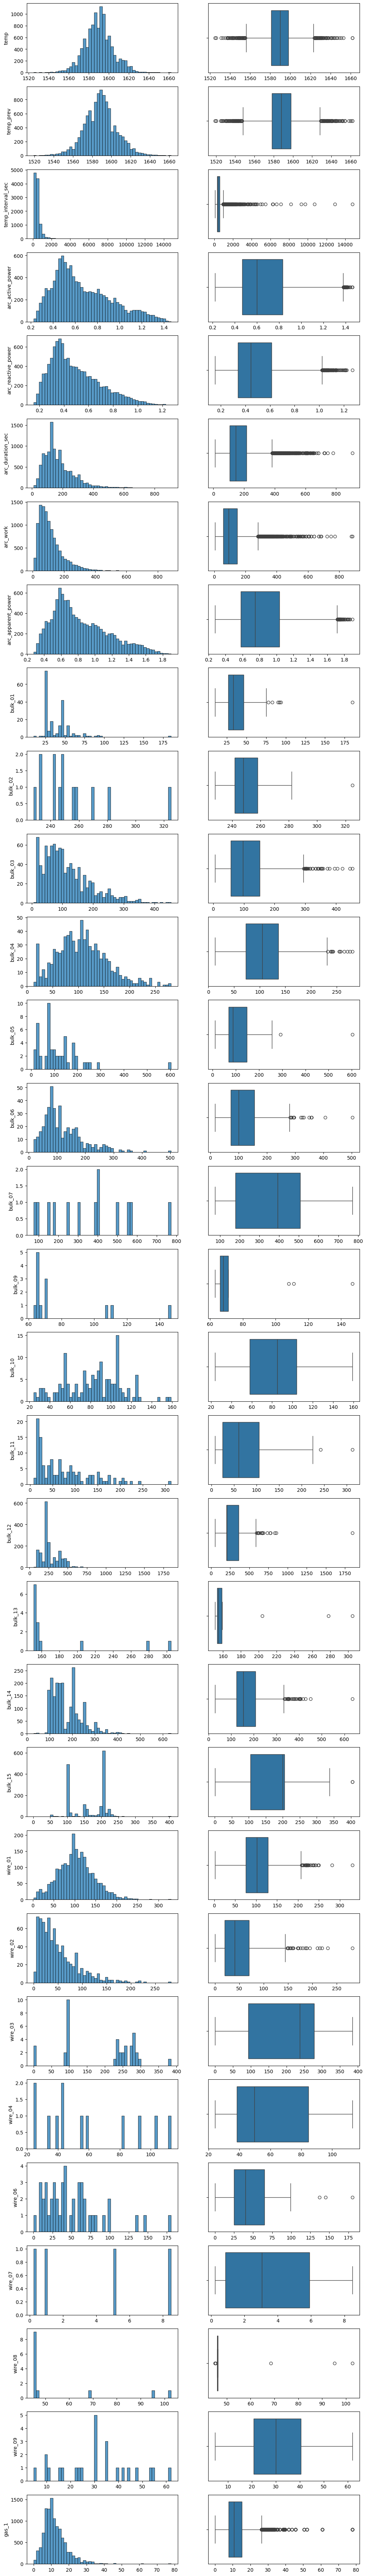

In [43]:
plot_num_cont(data_all_nans)

### Корреляция между признаками

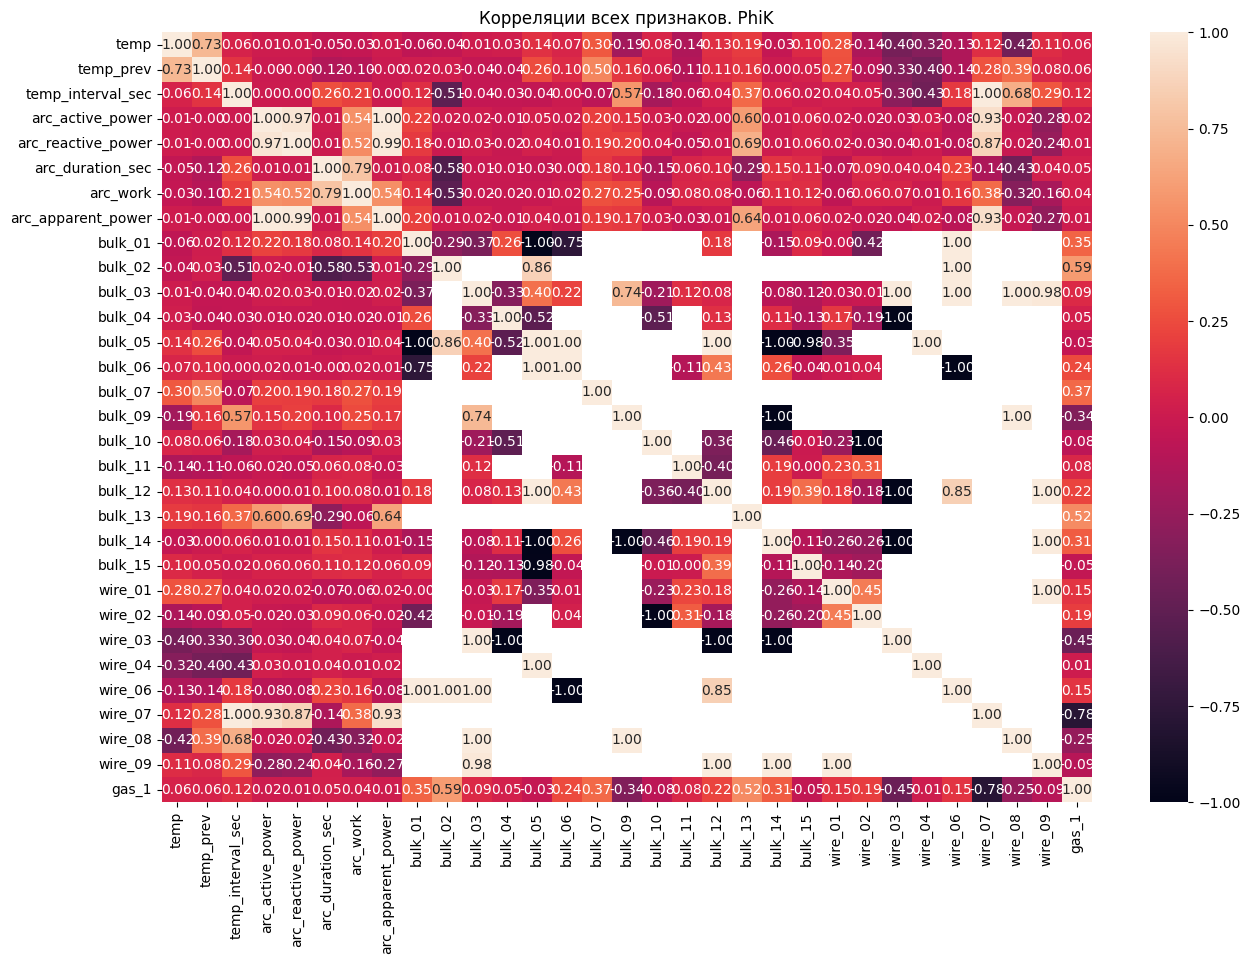

In [44]:
num_col_list = data_all_nans.select_dtypes(include='number').columns.to_list()
corr_matrix = data_all_nans[num_col_list].corr()
plt.figure(figsize=(15, 10))
plot = sns.heatmap(corr_matrix, annot=True, fmt='.2f');
plot.set_title('Корреляции всех признаков. PhiK');

## Обучение

In [45]:
class Learn:
	random_state_	= 61026
	test_fraction_	= 0.25
	target_fld_		= 'temp'

	def __init__(self, df):
		x = df.drop(columns=Learn.target_fld_)
		y = df[Learn.target_fld_]
		self.x_train_, self.x_test_, self.y_train_, self.y_test_ =\
			train_test_split(x, y, test_size=Learn.test_fraction_, random_state=Learn.random_state_)

	def fit_linear_regression(self):
		self.pipe_lin_reg_ = Pipeline([
			('scaler', StandardScaler()),
			('regression', LinearRegression())
		]).fit(self.x_train_, self.y_train_)
		return self.pipe_lin_reg_

	def fit_tree(self):
		self.pipe_tree_ = Pipeline([
			('scaler', StandardScaler()),
			('regression', DecisionTreeRegressor())
		]).fit(self.x_train_, self.y_train_)
		return self.pipe_tree_

	def explore(self, estimator, x, y, label):
		print(f'{label} R2: {estimator.score(x, y):.04f}')
		y_pred = estimator.predict(x)
		print(f'{label}. MAE: {mean_absolute_error(y, y_pred):.04f}')
		y_df = pd.DataFrame({'y_true': y, 'y_pred': y_pred})
		y_df.loc[:, 'y_error'] = y_df['y_pred'] - y_df['y_true']

		fig, axs = plt.subplots(2, 2, figsize=(15, 10))
		sns.scatterplot(y_df, x='y_true', y='y_pred', ax=axs[0, 0]).set_title(f'{label}. Предсказания в пространстве таргета');
		sns.scatterplot(y_df, x='y_true', y='y_error', ax=axs[0, 1]).set_title(f'{label}. Ошибки в пространстве таргета');
		sns.histplot(y_df, x='y_error', ax=axs[1, 0]).set_title(f'{label}. Гистограмма ошибок');
		axs[1, 1].set_visible(False)

	def explore_train(self, estimator, label):
		self.explore(estimator, self.x_train_, self.y_train_, label + '.train')

	def explore_test(self, estimator, label):
		self.explore(estimator, self.x_test_, self.y_test_, label + '.train')

learn = Learn(data_all)

### Линейная регрессия

LinearRegression.train R2: 0.5556
LinearRegression.train. MAE: 7.0597


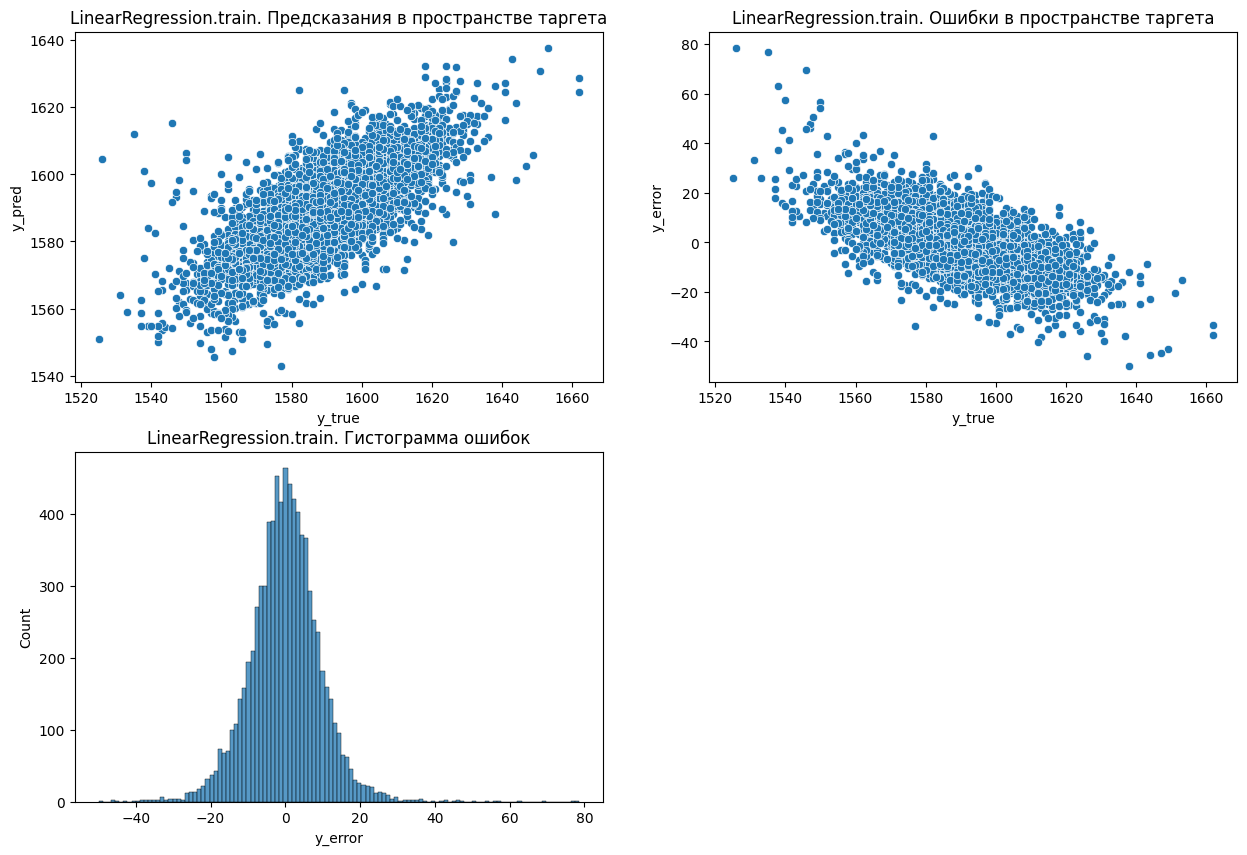

In [46]:
learn.explore_train(learn.fit_linear_regression(), 'LinearRegression')

### Дерево

DecisionTreeRegressor.train R2: 1.0000
DecisionTreeRegressor.train. MAE: 0.0000


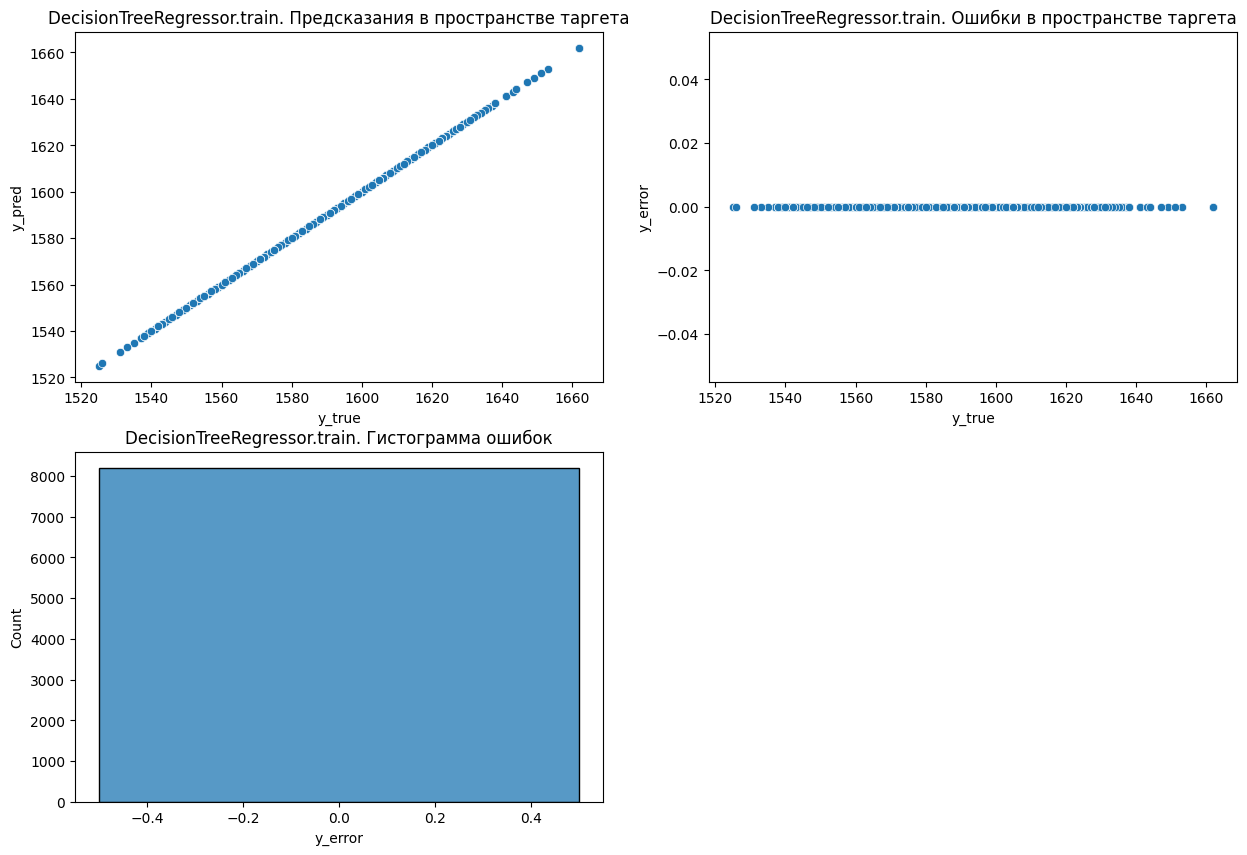

In [47]:
learn.explore_train(learn.fit_tree(), 'DecisionTreeRegressor')